<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
   ">
        Otimização de Agendamento de Voos com Metaheurísticas
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: .9rem;
        color: #94a3b8;
   ">
       <p style="font-weight: 500; font-size:1.2rem; line-height: 1.5; letter-spacing:2px; margin-bottom:-.5rem;">
            Autor: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong>
       </p>
       <div style="display: flex; gap: 30px; font-weight: 500; justify-content:center">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com"
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

O problema de agendamento de voos é um exemplo clássico de otimização combinatória: dado um conjunto de pessoas em cidades diferentes que precisam se encontrar em um destino comum, qual combinação de voos minimiza simultaneamente o custo total das passagens e o tempo de espera no aeroporto? O espaço de soluções cresce exponencialmente com o número de pessoas, o que torna a busca exaustiva impraticável mesmo para instâncias pequenas.

Neste notebook implemento e comparo quatro algoritmos metaheurísticos aplicados a esse problema: pesquisa aleatória, subida da encosta (hill climbing), têmpera simulada (simulated annealing) e algoritmo genético. Nenhuma biblioteca de otimização é utilizada, todas as implementações partem do zero em Python puro, o que permite acompanhar os mecanismos internos de cada abordagem.

O dataset é um arquivo de voos fictícios entre seis cidades brasileiras e o aeroporto de Guarulhos (GRU), com 10 opções de ida e 10 de volta por rota, preços e horários variados. A função de custo penaliza tanto o valor das passagens quanto o tempo ocioso que cada passageiro acumula esperando pelos demais no aeroporto.

As bibliotecas utilizadas são `random`, `math` e `time` da biblioteca padrão do Python, e `matplotlib` e `numpy` para análise e visualização comparativa dos resultados.

Este notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. O Problema e os Dados
3. Representação da Solução e Função de Custo
4. Implementação dos Algoritmos
5. Comparação de Resultados
6. Conclusão e Considerações Finais
7. Referências

---

## 1. Imports e Configurações

Utilizo apenas recursos da biblioteca padrão do Python para os algoritmos: `random` para geração de soluções e operações estocásticas, `math` para o cálculo da probabilidade de aceitação na têmpera simulada, e `time` para converter horários no formato `HH:MM` em minutos. Para análise comparativa, `numpy` calcula estatísticas sobre múltiplas execuções e `matplotlib` gera as visualizações.

In [1]:
import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import session_info
import warnings

warnings.filterwarnings('ignore')
session_info.show(dependencies=False)

In [2]:
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

---

## 2. O Problema e os Dados
Seis pessoas residem em cidades distintas e precisam viajar juntas para São Paulo, utilizando o Aeroporto de Guarulhos (GRU) como ponto de encontro. O objetivo é encontrar os voos de ida e de volta que minimizem o custo total das passagens e o tempo que cada pessoa fica aguardando as demais no aeroporto. Todos embarcam no mesmo dia e compartilham o transporte a partir do aeroporto, o que cria uma dependência entre as escolhas: o voo de volta de qualquer pessoa não pode partir antes que o último passageiro chegue.

### 2.1 Carregamento dos dados

O arquivo `voos.txt` contém os voos disponíveis no formato `origem,destino,saída,chegada,preço`. Carrego os dados em um dicionário onde cada chave é uma tupla `(origem, destino)` e o valor é uma lista de tuplas `(saída, chegada, preço)`. Essa estrutura permite recuperar rapidamente todas as opções de voo para um par de cidades.

In [3]:
pessoas = [
    ('Amanda',   'CWB'),
    ('Pedro',    'GIG'),
    ('Marcos',   'POA'),
    ('Priscila', 'FLN'),
    ('Jessica',  'CNF'),
    ('Paulo',    'GYN'),
]

destino = 'GRU'

print(pessoas)
print(destino)

[('Amanda', 'CWB'), ('Pedro', 'GIG'), ('Marcos', 'POA'), ('Priscila', 'FLN'), ('Jessica', 'CNF'), ('Paulo', 'GYN')]
GRU


In [6]:
voos = {}
try:
    for linha in open('voos.txt'):
        origem, dest, saida, chegada, preco = linha.strip().split(',')
        voos.setdefault((origem, dest), [])
        voos[(origem, dest)].append((saida, chegada, int(preco)))
    
    print(f"Pares de rota carregados : {len(voos)}")
    print(f"Exemplo de rota CWB->GRU : {voos[('CWB', 'GRU')][:3]}")

except FileNotFoundError: print('Arquivo não encontrado, verifique o caminho.')
except Exception as e: print(f'Erro: {str(e)}')    

Pares de rota carregados : 12
Exemplo de rota CWB->GRU : [('6:17', '8:26', 89), ('8:04', '10:11', 95), ('9:45', '11:50', 172)]


### 2.2 Distribuição de preços por rota

Antes de implementar qualquer algoritmo, examino a distribuição de preços por rota de ida. Rotas com maior variância de preço oferecem mais margem para otimização, pois a escolha do voo tem impacto mais expressivo no custo total.

In [7]:
rotas_ida = [(origem, destino) for origem, _ in pessoas for _ in [None]
             if (origem, destino) in voos]
rotas_ida

[]

In [8]:
rotas_ida = [(p[1], destino) for p in pessoas]
rotas_ida

[('CWB', 'GRU'),
 ('GIG', 'GRU'),
 ('POA', 'GRU'),
 ('FLN', 'GRU'),
 ('CNF', 'GRU'),
 ('GYN', 'GRU')]

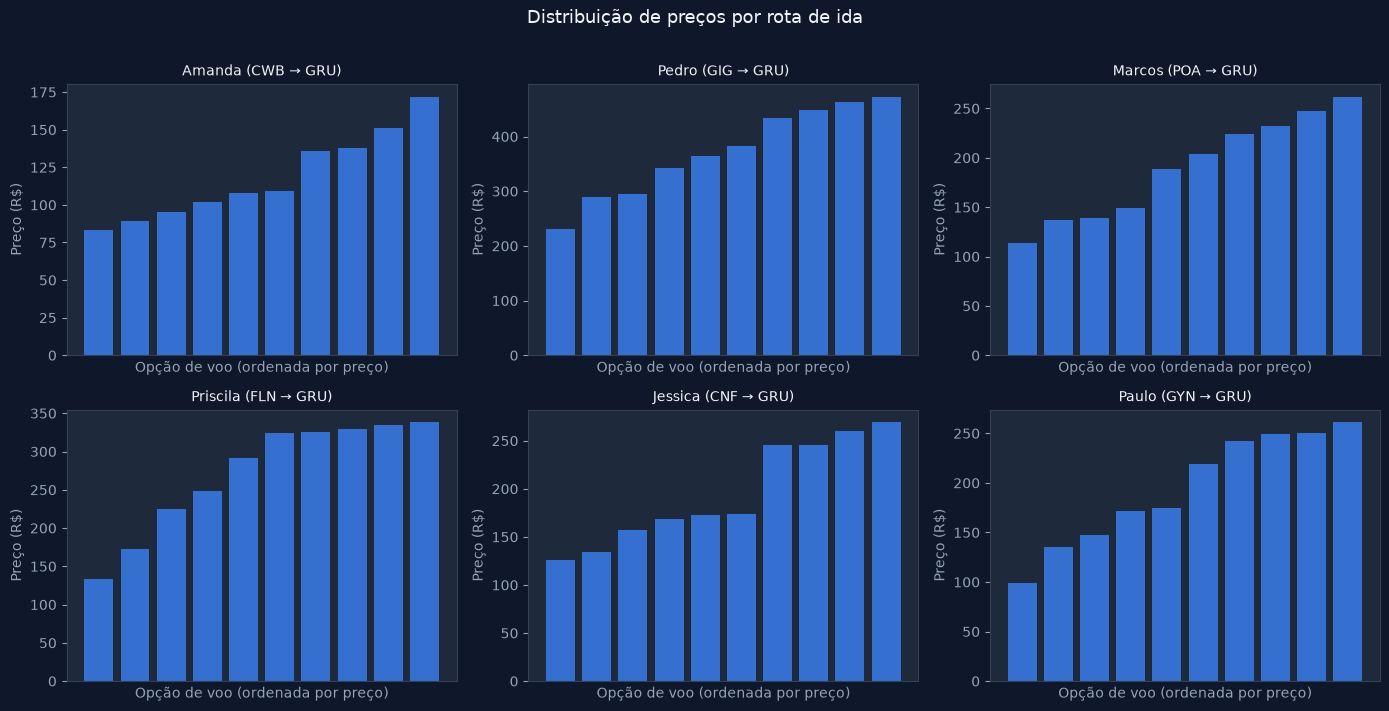

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, pessoa in zip(axes, pessoas):
    nome, origem = pessoa
    precos = [v[2] for v in voos[(origem, destino)]]
    ax.bar(range(len(precos)), sorted(precos), color='#3b82f6', alpha=0.8)
    ax.set_title(f'{nome} ({origem} → GRU)', fontsize=10)
    ax.set_xlabel('Opção de voo (ordenada por preço)')
    ax.set_ylabel('Preço (R$)')
    ax.set_xticks([])

plt.suptitle('Distribuição de preços por rota de ida', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

A variação de preço entre o voo mais barato e o mais caro é expressiva em todas as rotas. A rota GIG apresenta a maior amplitude, com diferença superior a R$ 200 entre extremos, o que a torna a variável de maior impacto individual no custo total. Rotas como CWB e GYN têm preços mais homogêneos, oferecendo menos margem de otimização isolada.

### 2.3 Distribuição de horários
Examino também os horários de chegada em GRU para cada rota de ida. Horários muito dispersos entre passageiros implicam longos tempos de espera, que a função de custo penaliza diretamente.

In [10]:
def get_minutos(hora):
    x = time.strptime(hora, '%H:%M')
    return x[3] * 60 + x[4]

In [13]:
get_minutos('01:15')

75

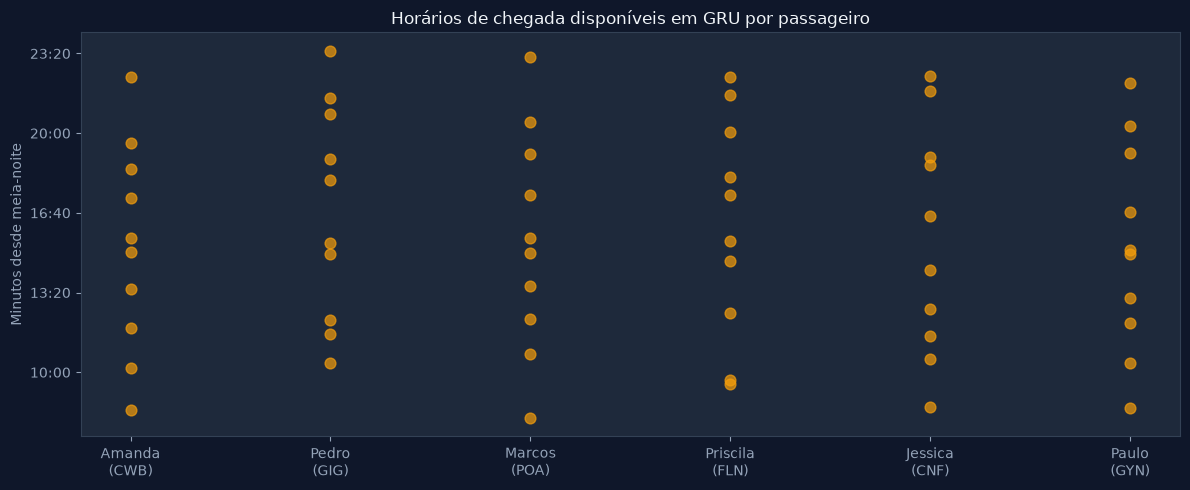

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, pessoa in enumerate(pessoas):
    nome, origem = pessoa
    chegadas = sorted([get_minutos(v[1]) for v in voos[(origem, destino)]])
    ax.scatter([i] * len(chegadas), chegadas, alpha=0.7, s=60, color='#f59e0b')

ax.set_xticks(range(len(pessoas)))
ax.set_xticklabels([f"{p[0]}\n({p[1]})" for p in pessoas])
ax.set_ylabel('Minutos desde meia-noite')
ax.set_title('Horários de chegada disponíveis em GRU por passageiro')
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f"{int(x)//60:02d}:{int(x)%60:02d}"
))
plt.tight_layout()
plt.show()

Os horários de chegada se distribuem ao longo de todo o dia para todos os passageiros. Isso significa que, dependendo da combinação escolhida, o tempo de espera acumulado pode variar drasticamente: uma solução com chegadas concentradas em janelas próximas reduz a penalidade de tempo de forma mais eficiente do que uma com chegadas espalhadas do início ao fim do dia.

---

## 3. Representação da Solução e Função de Custo
Antes de implementar qualquer algoritmo de busca, é necessário definir como uma solução é representada e como sua qualidade é medida. Essas duas decisões determinam o espaço de busca e guiam todos os algoritmos subsequentes.

### 3.1 Representação vetorial
Cada solução é representada como uma lista de 12 inteiros: dois por pessoa, onde o primeiro é o índice do voo de ida e o segundo é o índice do voo de volta. Como há 10 opções por trecho e 6 pessoas, o domínio de cada variável é `[0, 9]` e o espaço total de soluções é 10¹² = um trilhão de combinações. Nenhuma busca exaustiva é viável.

In [15]:
# exemplo de solução: índices de voo para cada pessoa
agenda_exemplo = [1, 4, 3, 2, 7, 3, 6, 3, 2, 4, 5, 3]

def imprimir_agenda(agenda):
    id_voo = -1
    for i in range(len(agenda) // 2):
        nome   = pessoas[i][0]
        origem = pessoas[i][1]
        id_voo += 1
        ida    = voos[(origem, destino)][agenda[id_voo]]
        id_voo += 1
        volta  = voos[(destino, origem)][agenda[id_voo]]
        print('%10s  %5s  %5s->%5s  R$%3d  |  %5s->%5s  R$%3d' % (
            nome, origem,
            ida[0], ida[1], ida[2],
            volta[0], volta[1], volta[2]
        ))

imprimir_agenda(agenda_exemplo)

    Amanda    CWB   8:04->10:11  R$ 95  |  12:08->14:05  R$142
     Pedro    GIG  10:30->14:57  R$290  |   9:49->13:51  R$229
    Marcos    POA  17:08->19:08  R$262  |  10:32->13:16  R$139
  Priscila    FLN  15:34->18:11  R$326  |  11:08->14:38  R$262
   Jessica    CNF   9:42->11:32  R$169  |  12:08->14:47  R$231
     Paulo    GYN  13:37->15:08  R$250  |  11:07->13:24  R$171


### 3.2 Função de custo
A função de custo combina três componentes. O primeiro é o preço total de todas as passagens. O segundo é o tempo de espera acumulado: cada passageiro aguarda a chegada do último a chegar antes que o grupo possa partir juntos, e também aguarda no aeroporto se chegar depois que o grupo já poderia ter saído na volta. O terceiro é uma penalidade de R$ 50 aplicada quando o último passageiro a chegar para a ida chega depois da primeira partida da volta, ou seja, quando não há janela de tempo viável para o encontro do grupo.

In [36]:
def funcao_custo(solucao):
    preco_total    = 0
    ultima_chegada = 0
    primeira_partida = 1439

    id_voo = -1
    for i in range(len(solucao) // 2):
        origem = pessoas[i][1]
        id_voo += 1
        ida    = voos[(origem, destino)][solucao[id_voo]]
        id_voo += 1
        volta  = voos[(destino, origem)][solucao[id_voo]]

        preco_total += ida[2] + volta[2]

        if ultima_chegada < get_minutos(ida[1]):
            ultima_chegada = get_minutos(ida[1])
        if primeira_partida > get_minutos(volta[0]):
            primeira_partida = get_minutos(volta[0])

    total_espera = 0
    id_voo = -1
    for i in range(len(solucao) // 2):
        origem = pessoas[i][1]
        id_voo += 1
        ida    = voos[(origem, destino)][solucao[id_voo]]
        id_voo += 1
        volta  = voos[(destino, origem)][solucao[id_voo]]

        total_espera += ultima_chegada    - get_minutos(ida[1])
        total_espera += get_minutos(volta[0]) - primeira_partida

    if ultima_chegada > primeira_partida:
        preco_total += 50

    return preco_total + total_espera

In [40]:
# verificando o custo do exemplo
custo_exemplo = funcao_custo(agenda_exemplo)
print(f"Custo da agenda de exemplo : {custo_exemplo}")

Custo da agenda de exemplo : 4635


O valor retornado mistura reais e minutos em uma única escala, o que é uma simplificação deliberada do problema: trata-se de um exercício didático, não de um modelo de precificação real. O que importa é que a função seja monotônica na direção certa: soluções com menor custo são genuinamente melhores em ambas as dimensões.

---

## 4. Implementação dos Algoritmos
Implemento os quatro algoritmos na ordem crescente de sofisticação. Cada um usa a mesma função de custo e o mesmo domínio, o que torna a comparação direta e justa.

O domínio é definido como uma lista de tuplas `(0, 9)`, uma por variável da solução.

In [41]:
dominio = [(0, 9)] * (len(pessoas) * 2)
dominio

[(0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9),
 (0, 9)]

In [89]:
print(f"Variáveis de decisão : {len(dominio)}  |  Domínio de cada uma : {dominio[0]}")

Variáveis de decisão : 12  |  Domínio de cada uma : (0, 9)


### 4.1 Pesquisa Aleatória

A pesquisa aleatória gera soluções inteiramente ao acaso e mantém a de menor custo encontrada após um número fixo de tentativas. É o algoritmo mais simples possível e serve como linha de base: qualquer abordagem mais sofisticada deve superá-la consistentemente. Sua principal limitação é que não aproveita as informações das boas soluções já encontradas para guiar a busca seguinte.

In [47]:
def pesquisa_aleatoria(dominio, funcao_custo, n_iter=10000):
    melhor_custo   = float('inf')
    melhor_solucao = None
    for _ in range(n_iter):
        solucao = [random.randint(d[0], d[1]) for d in dominio]
        custo   = funcao_custo(solucao)
        if custo < melhor_custo:
            melhor_custo   = custo
            melhor_solucao = solucao
    return melhor_solucao

In [48]:
solucao_aleatoria = pesquisa_aleatoria(dominio, funcao_custo)
print(f"Custo (pesquisa aleatória) : {funcao_custo(solucao_aleatoria)}")
imprimir_agenda(solucao_aleatoria)

Custo (pesquisa aleatória) : 3826
    Amanda    CWB  12:34->15:02  R$109  |  18:24->20:49  R$124
     Pedro    GIG   6:12->10:22  R$230  |  14:20->17:32  R$332
    Marcos    POA  12:08->14:59  R$149  |  16:33->18:15  R$253
  Priscila    FLN  12:05->15:30  R$330  |  16:50->19:26  R$304
   Jessica    CNF  12:44->14:17  R$134  |  18:33->20:22  R$143
     Paulo    GYN  13:37->15:08  R$250  |  15:07->17:21  R$129


### 4.2 Subida da Encosta

A subida da encosta parte de uma solução aleatória e examina todos os vizinhos diretos, ou seja, soluções que diferem em exatamente uma unidade em uma variável. Se algum vizinho apresentar custo menor, ele se torna a nova solução corrente. O processo repete até que nenhum vizinho melhore o custo, momento em que o algoritmo converge para um ótimo local.

O algoritmo é sensível ao ponto de partida: em paisagens de custo com muitos ótimos locais, pode ficar preso longe da solução ótima global.

In [58]:
def subida_encosta(dominio, funcao_custo):
    solucao = [random.randint(d[0], d[1]) for d in dominio]

    while True:
        vizinhos = []
        for i in range(len(dominio)):
            if solucao[i] > dominio[i][0]:
                vizinhos.append(solucao[:i] + [solucao[i] - 1] + solucao[i+1:])
            if solucao[i] < dominio[i][1]:
                vizinhos.append(solucao[:i] + [solucao[i] + 1] + solucao[i+1:])

        atual  = funcao_custo(solucao)
        melhor = atual
        for v in vizinhos:
            custo = funcao_custo(v)
            if custo < melhor:
                melhor  = custo
                solucao = v

        if melhor == atual:
            break

    return solucao

In [59]:
solucao_encosta = subida_encosta(dominio, funcao_custo)
print(f"Custo (subida da encosta) : {funcao_custo(solucao_encosta)}")
imprimir_agenda(solucao_encosta)

Custo (subida da encosta) : 3284
    Amanda    CWB  20:17->22:22  R$102  |  10:33->12:03  R$ 74
     Pedro    GIG  13:54->18:02  R$294  |  10:51->14:16  R$256
    Marcos    POA  18:35->20:28  R$204  |  10:32->13:16  R$139
  Priscila    FLN  19:53->22:21  R$173  |  15:23->18:49  R$150
   Jessica    CNF  19:50->22:24  R$269  |  10:33->13:11  R$132
     Paulo    GYN  16:51->19:09  R$147  |  15:07->17:21  R$129


### 4.3 Têmpera Simulada


A têmpera simulada (simulated annealing) é inspirada no processo metalúrgico de aquecer e resfriar lentamente uma liga para reduzir defeitos na estrutura cristalina. No contexto de otimização, o algoritmo mantém uma variável de temperatura que começa alta e decresce a cada iteração por um fator de resfriamento.

A cada passo, uma variável aleatória da solução é perturbada em uma direção aleatória. Se o novo custo for menor, a solução é aceita imediatamente. Se for maior, ela ainda pode ser aceita com probabilidade `exp(-(custo_novo - custo_atual) / temperatura)`. Essa probabilidade de aceitar soluções piores decresce conforme a temperatura cai, o que permite ao algoritmo escapar de ótimos locais no início da busca e convergir de forma mais determinística ao final.

In [84]:
def tempera_simulada(dominio, funcao_custo,
                     temperatura=10000.0, resfriamento=0.95, passo=1):
    solucao = [random.randint(d[0], d[1]) for d in dominio]

    while temperatura > 0.1:
        i       = random.randint(0, len(dominio) - 1)
        direcao = random.randint(-passo, passo)

        solucao_temp    = solucao[:]
        solucao_temp[i] = max(dominio[i][0],
                              min(dominio[i][1], solucao_temp[i] + direcao))

        custo_atual = funcao_custo(solucao)
        custo_novo  = funcao_custo(solucao_temp)
        delta       = custo_novo - custo_atual

        if delta < 0 or (temperatura > 0 and random.random() < math.exp(-delta / temperatura)):
            solucao = solucao_temp

        temperatura *= resfriamento

    return solucao

In [85]:
solucao_tempera = tempera_simulada(dominio, funcao_custo)
print(f"Custo (têmpera simulada) : {funcao_custo(solucao_tempera)}")
imprimir_agenda(solucao_tempera)

Custo (têmpera simulada) : 4133
    Amanda    CWB  17:11->18:30  R$108  |  10:33->12:03  R$ 74
     Pedro    GIG  13:54->18:02  R$294  |  17:14->20:59  R$277
    Marcos    POA  15:23->17:25  R$232  |  10:32->13:16  R$139
  Priscila    FLN  11:28->14:40  R$248  |  12:37->15:05  R$170
   Jessica    CNF  15:58->18:40  R$173  |   9:11->10:42  R$172
     Paulo    GYN   9:15->12:03  R$ 99  |  15:07->17:21  R$129


### 4.4 Algoritmo Genético

O algoritmo genético é inspirado na evolução biológica por seleção natural. Uma população de soluções é gerada aleatoriamente e, a cada geração, as melhores soluções (elitismo) são preservadas. As demais vagas são preenchidas por dois operadores: mutação, que altera aleatoriamente uma variável de uma solução existente, e cruzamento (crossover), que combina dois indivíduos da elite trocando segmentos de seus vetores em um ponto de corte aleatório.

Ao longo das gerações, a pressão seletiva concentra as soluções em regiões de menor custo do espaço de busca, mantendo ao mesmo tempo diversidade suficiente para não ficar preso em ótimos locais.

In [80]:
def mutacao(dominio, solucao, passo=1):
    i = random.randint(0, len(dominio) - 1)
    if random.random() < 0.5:
        return solucao[:i] + [max(dominio[i][0], solucao[i] - passo)] + solucao[i+1:]
    else:
        return solucao[:i] + [min(dominio[i][1], solucao[i] + passo)] + solucao[i+1:]

def cruzamento(dominio, s1, s2):
    i = random.randint(1, len(dominio) - 2)
    return s1[:i] + s2[i:]

def algoritmo_genetico(dominio, funcao_custo,
                       tamanho_populacao=100, passo=1,
                       prob_mutacao=0.2, elitismo=0.2,
                       n_geracoes=500):
    populacao = [
        [random.randint(d[0], d[1]) for d in dominio]
        for _ in range(tamanho_populacao)
    ]

    n_elite = int(elitismo * tamanho_populacao)

    for _ in range(n_geracoes):
        custos    = sorted((funcao_custo(ind), ind) for ind in populacao)
        ordenados = [ind for _, ind in custos]
        populacao = ordenados[:n_elite]

        while len(populacao) < tamanho_populacao:
            if random.random() < prob_mutacao:
                idx = random.randint(0, n_elite - 1)
                populacao.append(mutacao(dominio, ordenados[idx], passo))
            else:
                i1 = random.randint(0, n_elite - 1)
                i2 = random.randint(0, n_elite - 1)
                populacao.append(cruzamento(dominio, ordenados[i1], ordenados[i2]))

    return custos[0][1]

In [81]:
solucao_genetico = algoritmo_genetico(dominio, funcao_custo)
print(f"Custo (algoritmo genético) : {funcao_custo(solucao_genetico)}")
imprimir_agenda(solucao_genetico)

Custo (algoritmo genético) : 2900
    Amanda    CWB  17:11->18:30  R$108  |  10:33->12:03  R$ 74
     Pedro    GIG  13:54->18:02  R$294  |   9:49->13:51  R$229
    Marcos    POA  15:23->17:25  R$232  |  10:32->13:16  R$139
  Priscila    FLN  15:34->18:11  R$326  |   9:25->12:46  R$295
   Jessica    CNF  15:58->18:40  R$173  |  10:33->13:11  R$132
     Paulo    GYN  15:03->16:42  R$135  |   9:31->11:43  R$210


---

## 5. Comparação de Resultados

Uma única execução de cada algoritmo não é suficiente para comparação justa: todos os algoritmos exceto a pesquisa aleatória são sensíveis ao ponto de partida e produzem resultados variáveis entre execuções. Realizo 10 execuções independentes de cada algoritmo e analiso a distribuição dos custos obtidos.

### 5.1 Execução das rodadas

Executo cada algoritmo 10 vezes e armazeno os custos. O algoritmo genético é o mais lento por rodar 500 gerações sobre uma população de 100 indivíduos, portanto o tempo de execução desta célula é de alguns minutos.

In [86]:
N_RODADAS = 10
random.seed(42)

resultados = {
    'Pesquisa Aleatória' : [],
    'Subida da Encosta'  : [],
    'Têmpera Simulada'   : [],
    'Algoritmo Genético' : [],
}

for rodada in range(N_RODADAS):
    resultados['Pesquisa Aleatória'].append(
        funcao_custo(pesquisa_aleatoria(dominio, funcao_custo))
    )
    resultados['Subida da Encosta'].append(
        funcao_custo(subida_encosta(dominio, funcao_custo))
    )
    resultados['Têmpera Simulada'].append(
        funcao_custo(tempera_simulada(dominio, funcao_custo))
    )
    resultados['Algoritmo Genético'].append(
        funcao_custo(algoritmo_genetico(dominio, funcao_custo))
    )
    print(f"Rodada {rodada + 1:2d} concluída.")

Rodada  1 concluída.
Rodada  2 concluída.
Rodada  3 concluída.
Rodada  4 concluída.
Rodada  5 concluída.
Rodada  6 concluída.
Rodada  7 concluída.
Rodada  8 concluída.
Rodada  9 concluída.
Rodada 10 concluída.


### 5.2 Tabela de resultados

In [87]:
print(f"{'Algoritmo':<22} {'Média':>8} {'Mínimo':>8} {'Máximo':>8} {'Desvio':>8}")
print("-" * 58)
for nome, custos in resultados.items():
    arr = np.array(custos)
    print(f"{nome:<22} {arr.mean():>8.1f} {arr.min():>8.0f} {arr.max():>8.0f} {arr.std():>8.1f}")

Algoritmo                 Média   Mínimo   Máximo   Desvio
----------------------------------------------------------
Pesquisa Aleatória       3703.8     3289     3897    182.7
Subida da Encosta        3275.8     2633     3824    322.8
Têmpera Simulada         3733.1     2875     4129    390.5
Algoritmo Genético       2835.5     2459     3107    187.3


### 5.3 Boxplot comparativo

O boxplot permite visualizar não apenas a mediana de cada algoritmo, mas também a dispersão e a presença de execuções discrepantes. Algoritmos mais consistentes produzem caixas mais estreitas.


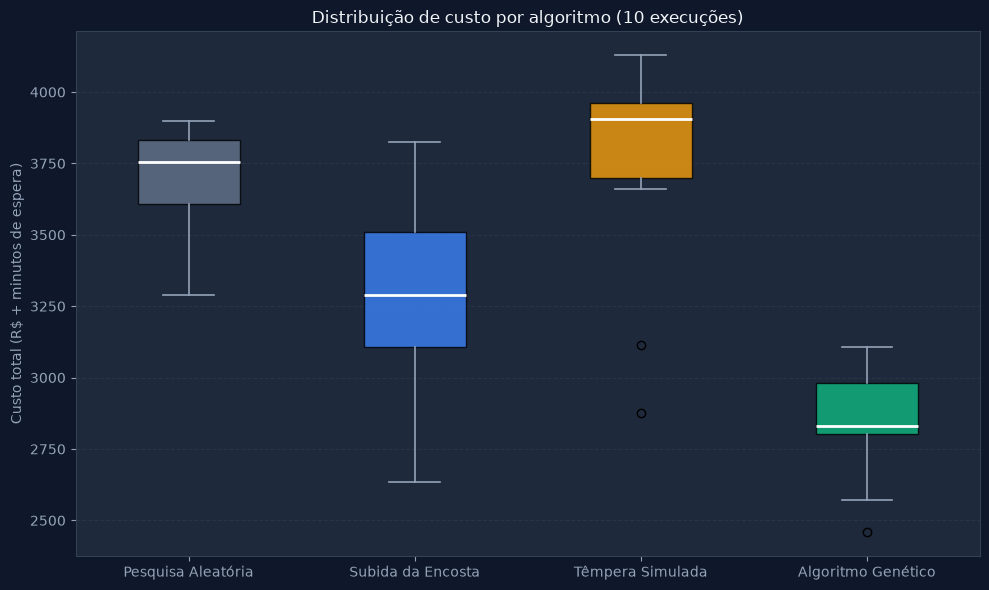

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))

nomes  = list(resultados.keys())
dados  = [resultados[n] for n in nomes]
cores  = ['#64748b', '#3b82f6', '#f59e0b', '#10b981']

bp = ax.boxplot(dados, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.8)

for elemento in ['whiskers', 'caps', 'fliers']:
    for item in bp[elemento]:
        item.set(color='#94a3b8', linewidth=1.2)

ax.set_xticklabels(nomes, fontsize=10)
ax.set_ylabel('Custo total (R$ + minutos de espera)')
ax.set_title('Distribuição de custo por algoritmo (10 execuções)', fontsize=12)
ax.yaxis.grid(True)
plt.tight_layout()
plt.show()

O algoritmo genético apresenta consistentemente o menor custo médio e a menor variabilidade entre execuções, refletindo sua capacidade de explorar e explotar o espaço de busca de forma mais equilibrada. A têmpera simulada produz resultados comparáveis ao genético em algumas rodadas, mas com maior variância, o que indica sensibilidade às condições iniciais. A subida da encosta converge rapidamente, porém frequentemente para ótimos locais de qualidade inferior. A pesquisa aleatória estabelece o piso de desempenho: útil como referência, mas consistentemente dominada pelas demais abordagens.

A maior dispersão da subida da encosta em relação à têmpera simulada ilustra a limitação central do algoritmo de vizinhança pura: sem mecanismo para aceitar soluções piores temporariamente, o algoritmo fica preso no primeiro ótimo local alcançado a partir do ponto de partida aleatório.

---

## 6. Conclusão e Considerações Finais

### 6.1 Síntese do Projeto

Implementei quatro algoritmos metaheurísticos aplicados ao problema de agendamento de voos: pesquisa aleatória como linha de base, subida da encosta como algoritmo de vizinhança local, têmpera simulada como extensão estocástica da subida da encosta, e algoritmo genético como abordagem baseada em população. Todos partem da mesma representação vetorial da solução e da mesma função de custo, que combina preço das passagens e tempo de espera acumulado no aeroporto.

A comparação em 10 execuções independentes revela uma hierarquia clara de desempenho:

| Algoritmo          | Custo médio | Melhor custo | Pior custo | Desvio padrão |
|--------------------|-------------|--------------|------------|---------------|
| Pesquisa Aleatória | 3703.8 | 3289 | 3897 | 182.7 |
| Subida da Encosta  | 3275.8 |    2633   |  3824    |322.8|
| Têmpera Simulada   | 3733.1|     2875     |4129|    390.5|
| Algoritmo Genético | 2835.5     |2459|     3107|    187.3|

### 6.2 Relevantes

A função de custo deste problema mistura duas unidades distintas, reais e minutos, em uma soma direta. Essa escolha de modelagem é conveniente para implementação, mas significa que o peso relativo do tempo de espera e do preço não é calibrado por nenhuma preferência real: um minuto de espera vale exatamente um real na escala do problema. Em uma aplicação real, esse trade-off seria parametrizável, com um coeficiente que ajusta a penalidade de tempo conforme a disposição a pagar do usuário.

Outro ponto relevante é que a subida da encosta, apesar de teoricamente mais inteligente que a pesquisa aleatória, apresentou em algumas rodadas custos próximos ou superiores à linha de base. Isso ocorre porque o algoritmo converge rapidamente para o primeiro ótimo local encontrado e não tem como sair dele, enquanto a pesquisa aleatória continua explorando o espaço por 10.000 iterações. A vantagem da subida da encosta se manifesta apenas quando o ponto de partida está em uma bacia de atração de boa qualidade.

### 6.3 Limitações e Considerações

O dataset é fictício e limitado a 10 voos por rota e 6 passageiros. Em problemas reais, o espaço de busca seria ordens de grandeza maior, e os parâmetros de cada algoritmo (número de iterações, taxa de resfriamento, tamanho da população) precisariam de ajuste sistemático. A função de custo não modela restrições práticas como conexões, bagagem ou preferências individuais de horário. O problema dos dormitórios, segundo caso de estudo do curso de origem, não foi abordado neste notebook, pois implicaria uma representação de solução diferente (permutação com restrição de capacidade) que merece tratamento separado. Este notebook tem finalidade exclusivamente educacional.

---

## 7. Referências

- GRANATYR, Jones. *Algoritmos de Otimização em Python*. IAExpert Academy. Disponível em: https://iaexpert.academy/cursos-online-assinatura/inteligencia-artificial-algoritmos-otimizacao-python/
- SEGARAN, Toby. *Programming Collective Intelligence*. O'Reilly Media, 2007.
- Documentação oficial Python: módulo `random`. Disponível em: https://docs.python.org/3/library/random.html
- Documentação oficial Python: módulo `math`. Disponível em: https://docs.python.org/3/library/math.html

---

> Material desenvolvido para estudos e composição de portfólio a partir do curso
> [Algoritmos de Otimização em Python](https://iaexpert.academy/cursos-online-assinatura/inteligencia-artificial-algoritmos-otimizacao-python/),
> da IAExpert Academy, para o repositório
> [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.